In [1]:
# 建立學生成績單
import numpy as np
import pandas as pd

# 建立50學生，每個學生有5科成績
np.random.seed(54)  # 設定隨機種子以確保結果可重現
scores = np.random.randint(50, 101, size=(50, 5))

df_scores = pd.DataFrame(
    scores,
    columns=['國文', '英文', '數學', '自然', '社會'],
    index=range(1, 51)
)

# 設定欄的名稱和索引的名稱
df_scores.columns.name = '科目'
df_scores.index.name = '學生編號'

sum_scores = df_scores.sum(axis=1)
mean_scores = df_scores.mean(axis=1)

rank_scores = sum_scores.rank(method='min', ascending=False)

df_scores['總分'] = sum_scores
df_scores['平均'] = mean_scores
df_scores['排名'] = rank_scores

df_scores1 = df_scores.sort_values(by='排名')

# 顯示成績單
df_scores1


科目,國文,英文,數學,自然,社會,總分,平均,排名
學生編號,,,,,,,,
18,96,97,85,87,82,447,89.4,1.0
37,99,72,96,85,85,437,87.4,2.0
34,100,75,65,97,95,432,86.4,3.0
33,70,90,95,79,92,426,85.2,4.0
26,97,73,100,64,87,421,84.2,5.0
30,58,98,95,70,95,416,83.2,6.0
21,79,84,94,88,68,413,82.6,7.0
12,85,91,62,75,97,410,82.0,8.0
47,55,97,84,100,72,408,81.6,9.0


In [2]:
def call(x):
    #計算最高分,最低分,標準差,顯示到小數點後兩位
    return pd.Series({
        '最高分': f"{x.max():.2f}",
        '最低分': f"{x.min():.2f}",
        '標準差': f"{x.std():.2f}"
    })



df_scores1[['國文', '英文', '數學', '自然', '社會']].apply(call)

科目,國文,英文,數學,自然,社會
最高分,100.00,98.00,100.00,100.00,98.00
最低分,51.00,50.00,51.00,51.00,50.00
標準差,16.19,14.39,15.00,14.08,13.64


In [ ]:
def call2(x):
    #學生不及格數量
    return pd.Series({
        '不及格科目數': (x < 60).sum()
    })


df_scores1["不及格科目數"] = df_scores1[['國文', '英文', '數學', '自然', '社會']].apply(call2, axis=1)
df_scores1

科目,國文,英文,數學,自然,社會,總分,平均,排名,不及格科目數
學生編號,,,,,,,,,
18,96,97,85,87,82,447,89.4,1.0,0
37,99,72,96,85,85,437,87.4,2.0,0
34,100,75,65,97,95,432,86.4,3.0,0
33,70,90,95,79,92,426,85.2,4.0,0
26,97,73,100,64,87,421,84.2,5.0,0
30,58,98,95,70,95,416,83.2,6.0,1
21,79,84,94,88,68,413,82.6,7.0,0
12,85,91,62,75,97,410,82.0,8.0,0
47,55,97,84,100,72,408,81.6,9.0,1


In [4]:
def call3(x):
    #傳出學生不及格的科目名稱, 以逗號分隔, 若無不及格科目則傳出"全部及格"
    failed_subjects = x.index[x < 60].tolist()
    if failed_subjects:
        return ', '.join(failed_subjects)
    else:
        return '全部及格'

df_scores1["不及格科目名稱"] = df_scores1[['國文', '英文', '數學', '自然', '社會']].apply(call3, axis=1)
df_scores1

科目,國文,英文,數學,自然,社會,總分,平均,排名,不及格科目數,不及格科目名稱
學生編號,,,,,,,,,,
18,96,97,85,87,82,447,89.4,1.0,0,全部及格
37,99,72,96,85,85,437,87.4,2.0,0,全部及格
34,100,75,65,97,95,432,86.4,3.0,0,全部及格
33,70,90,95,79,92,426,85.2,4.0,0,全部及格
26,97,73,100,64,87,421,84.2,5.0,0,全部及格
30,58,98,95,70,95,416,83.2,6.0,1,國文
21,79,84,94,88,68,413,82.6,7.0,0,全部及格
12,85,91,62,75,97,410,82.0,8.0,0,全部及格
47,55,97,84,100,72,408,81.6,9.0,1,國文


In [5]:
# 某財務軟體公司在全國有許多代理商，
# 為研究它的財務軟體產品的廣告投入與銷售額的關係，
# 統計人員隨機選擇10家代理商進行觀察，
# 蒐集到年度廣告投入與月平均銷售額的數據，
# 並進行生成相關表
# 相關係數計算

import pandas as pd
import numpy as np

data = {
    '年度廣告投入': [12.5, 15.3, 23.2, 26.4, 33.5, 34.4, 39.4, 45.2, 55.4, 60.9],
    '月均銷售額': [21.2, 23.9, 32.9, 34.1, 42.5, 43.2, 49.0, 52.8, 59.4, 63.5]
}

data_df = pd.DataFrame(
    data,
    index=[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
)

print(data_df)

# 計算相關係數
data_df.corr()


      年度廣告投入  月均銷售額
2011    12.5   21.2
2012    15.3   23.9
2013    23.2   32.9
2014    26.4   34.1
2015    33.5   42.5
2016    34.4   43.2
2017    39.4   49.0
2018    45.2   52.8
2019    55.4   59.4
2020    60.9   63.5


,年度廣告投入,月均銷售額
年度廣告投入,1.000000,0.994198
月均銷售額,0.994198,1.000000


In [7]:
# 安裝 wget（若已安裝可略過）
# %pip install wget

import wget

# 下載中文字型檔（直接從你的截圖來源 Repository）
font_url = "https://github.com/roberthsu2003/machine_learning/raw/refs/heads/main/source_data/ChineseFont.ttf"
wget.download(font_url, "ChineseFont.ttf")

import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

# 將字型加入 Matplotlib
fontManager.addfont("ChineseFont.ttf")

# 設定 Matplotlib 使用此字型
plt.rc('font', family="ChineseFont")


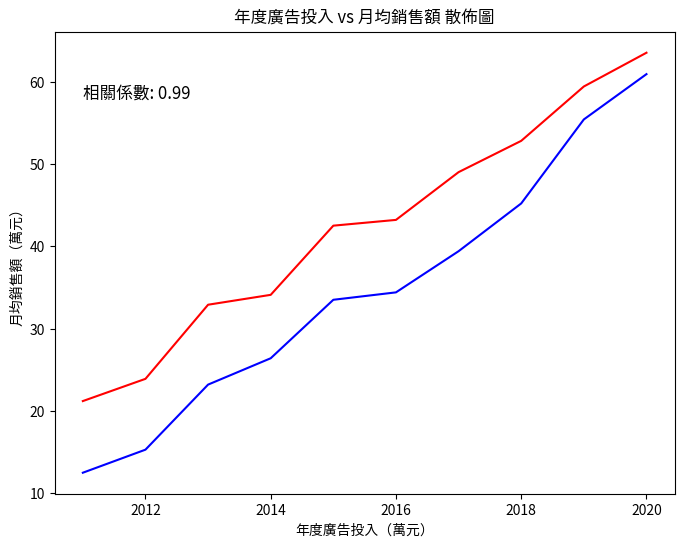

In [9]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8, 6))
axes = figure.add_subplot(1, 1, 1)

# 改變 marker 顏色
axes.plot(data_df.index, data_df['月均銷售額'], color='red')
axes.plot(data_df.index, data_df['年度廣告投入'], color='blue')

# 加入Correlation係數文字
correlation = data_df['年度廣告投入'].corr(data_df['月均銷售額'])
axes.text(2011, 58, f'相關係數: {correlation:.2f}', fontsize=12, color='black')


axes.set_title('年度廣告投入 vs 月均銷售額 散佈圖')
axes.set_xlabel('年度廣告投入（萬元）')
axes.set_ylabel('月均銷售額（萬元）')

plt.show()